# Фильтр частиц по правдоподобию (3.2)

Модель: скрытая цепь $\theta_t$ ($N$ состояний, генератор $\Lambda$) с меткой
$Y_t$, которая переразыгрывается при каждом скачке $\theta$ независимо от
прошлого и постоянна между скачками. При фиксированной траектории сигнала
$Z_t = (\theta_t, Y_t)$ на шаге $[t_{k-1}, t_k]$ длины $h$ приращение
наблюдения условно гауссовское (3.1)-(3.2):

$$
\Delta\xi_k \mid Z_{[t_{k-1}, t_k]} \sim N(F, G), \qquad
F = \sum_i \Delta\alpha_i\, f(\theta_{\alpha_i}, Y_{\alpha_i}), \qquad
G = \sum_i \Delta\alpha_i\, (gg^\top)(\theta_{\alpha_i}, Y_{\alpha_i}),
$$

где $\Delta\alpha_i$ -- времена пребывания в состояниях траектории внутри
шага, а $f$, $gg^\top$ -- снос и дисперсия каналов наблюдения (те же, что
`config.py` кладёт в `C`).

**Бутстрэп-фильтр частиц** (`ParticleFilter`): частица $i$ несёт пару
$(\theta^i, Y^i)$ и вес $w^i$. Шаг `update`:

1. ленивый ресемплинг в начале шага, если ESS упал ниже порога;
2. распространение частицы по априорной динамике -- траектория $\theta$
   разыгрывается на шаге точно так же, как в `core.smjp.sparse_mc`
   (экспоненциальные времена до скачка, выбор нового состояния по
   $\Lambda$, метка $Y$ из $\pi$);
3. вес домножается на плотность (3.2), вычисленную по реализовавшейся
   внутри шага траектории;
4. нормировка весов.

**Отличия от сеточного фильтра (`core/filter.py`)**:

* **нет сетки по $Y$** -- метка каждой частицы хранится точным вещественным
  значением, разыгранным из $\pi^m$, а не аппроксимируется узлами сетки;
* **нет обрыва ряда по числу скачков внутри шага** -- траектория частицы
  разыгрывается циклом `while` до исчерпания шага целиком, тогда как
  сеточный фильтр в этом ноутбуке (`two_jumps=False`) учитывает не больше
  одного скачка $\theta$ на шаг;
* зато частицы вносят **статистическую погрешность** порядка
  $1/\sqrt{n_{\text{particles}}}$, которая не убывает с измельчением сетки
  и не исчезает при $h \to 0$ -- убывает только с ростом числа частиц.

Конфиг `toy_particle_gauss` (раздел 4 статьи): 3 состояния $\theta$ с
непересекающимися носителями $Y$; наблюдение имеет нулевой снос и дисперсию,
равную $Y$ -- стресс-тест на информацию, содержащуюся только в интенсивности
шума.

In [1]:
import _bootstrap  # noqa: F401

import time

import numpy as np
import matplotlib.pyplot as plt

from discretized_filter.config import set_config
from discretized_filter.core.smjp import sparse_mc
from discretized_filter.core.filter import Filter
from discretized_filter.core.particle_filter import ParticleFilter
from discretized_filter.utils.grids import to_discrete, set_seed
from discretized_filter.visualization.plots import plot_theta_background

cfg = set_config('toy_particle_gauss')

print(f'N={cfg.N}, M={cfg.M}, K={cfg.K}, '
      f'шагов={cfg.t_net_filtering.shape[0]}, узлов сетки={cfg.M_net.shape[1]}')


N=3, M=1, K=1, шагов=10000, узлов сетки=64


In [2]:
theta, y, t = sparse_mc(cfg.p0, cfg.Lambda, cfg.lam, cfg.T, cfg.get_y, cfg.y_intervals)
observations = cfg.get_obs(cfg.t_net_filtering, theta, y, t)

print(f'скачков theta: {len(t)}, шагов наблюдений: {observations.shape[0]}')


скачков theta: 11, шагов наблюдений: 9999


In [3]:
def run_grid_filter():
    f = Filter(
        cfg.pi_init, cfg.pi, cfg.M_net, cfg.C,
        cfg.N, cfg.Lambda, cfg.ht, cfg.delta, cfg.obs_density,
        n_points=cfg.n_points, two_jumps=cfg.two_jumps,
        filter_step=cfg.filter_step,
    )
    est = f.estimate()
    th, yy = [est[0]], [est[1]]
    for obs in observations:
        f.update(obs)
        est = f.estimate()
        th.append(est[0])
        yy.append(est[1])
    return np.array(th), np.array(yy)


t0 = time.perf_counter()
theta_grid, y_grid = run_grid_filter()
t_grid = time.perf_counter() - t0
print(f'сеточный фильтр: {t_grid:.2f} с')


сеточный фильтр: 11.32 с


In [4]:
def run_particle_filter(n_particles, seed=cfg.seed):
    # сеем оба ГПСЧ явно перед КАЖДЫМ прогоном: ``from_config`` c
    # ``seed=None`` (по умолчанию) их не трогает -- иначе повторное семя
    # посреди эксперимента сбило бы уже сгенерированные траекторию и
    # наблюдения (см. докстринг ParticleFilter.from_config)
    set_seed(seed)
    np.random.seed(seed)
    pf = ParticleFilter.from_config(cfg, n_particles=n_particles)
    est = pf.estimate()
    th, yy, ess = [est[0]], [est[1]], [pf.ess]
    for obs in observations:
        pf.update(obs)
        est = pf.estimate()
        th.append(est[0])
        yy.append(est[1])
        ess.append(pf.ess)
    return np.array(th), np.array(yy), np.array(ess)


pf_runs = {}
for n_particles in (2000, 20000):
    t0 = time.perf_counter()
    pf_runs[n_particles] = run_particle_filter(n_particles)
    dt = time.perf_counter() - t0
    print(f'фильтр частиц n={n_particles}: {dt:.2f} с')


фильтр частиц n=2000: 6.17 с
фильтр частиц n=20000: 43.10 с


In [5]:
dtheta = to_discrete(
    np.vstack([np.int64(theta == i) for i in range(cfg.N)]).T, t, cfg.T, cfg.ht
)
dY = to_discrete(y, t, cfg.T, cfg.ht)
n = dtheta.shape[0]


def rmse(est_theta, est_y):
    rt = np.sqrt(((dtheta - est_theta[:n]) ** 2).mean())
    ry = np.sqrt(((dY - est_y[:n]) ** 2).mean())
    return rt, ry


print(f'{"фильтр":<22} {"RMSE theta":>11} {"RMSE Y":>9}')
rt, ry = rmse(theta_grid, y_grid)
print(f'{"сеточный":<22} {rt:11.4f} {ry:9.4f}')
for n_particles, (th, yy, _) in pf_runs.items():
    rt, ry = rmse(th, yy)
    print(f'{"частицы, n=" + str(n_particles):<22} {rt:11.4f} {ry:9.4f}')


фильтр                  RMSE theta    RMSE Y
сеточный                    0.2933    0.0616
частицы, n=2000             0.2907    0.0618
частицы, n=20000            0.2963    0.0619


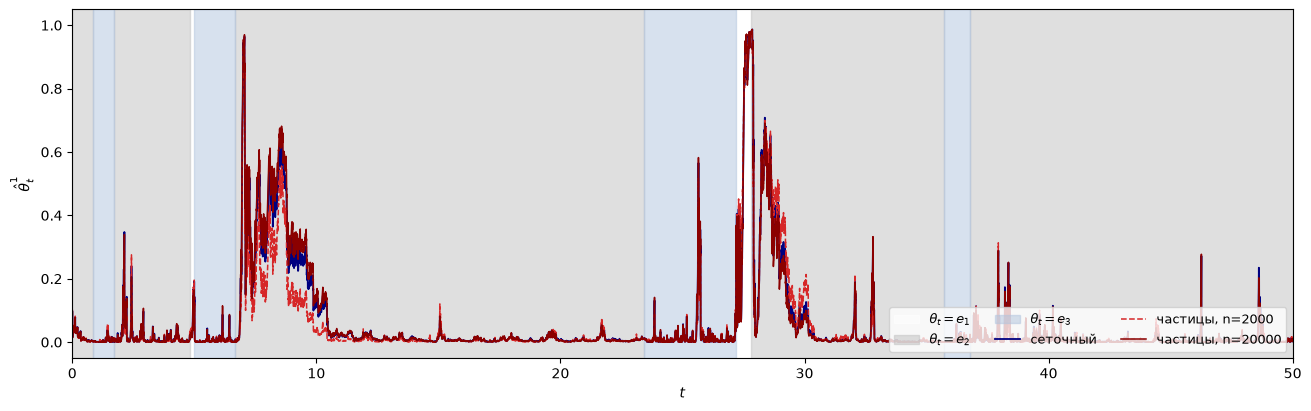

In [6]:
styles = {
    'сеточный': dict(color='navy', ls='-', lw=1.3),
    2000: dict(color='tab:red', ls='--', lw=1.1),
    20000: dict(color='darkred', ls='-', lw=1.1),
}

fig, ax = plt.subplots(figsize=(13, 4), layout='constrained')
plot_theta_background(
    ax, theta, t,
    ['$\\theta_t = e_1$', '$\\theta_t = e_2$', '$\\theta_t = e_3$'],
    ['white', 'silver', 'lightsteelblue'], 1, alpha=0.5
)
ax.plot(cfg.t_net_filtering, theta_grid[:, 0], label='сеточный', **styles['сеточный'])
for n_particles, (th, _, _) in pf_runs.items():
    ax.plot(cfg.t_net_filtering, th[:, 0], label=f'частицы, n={n_particles}',
            **styles[n_particles])
ax.set(xlabel='$t$', ylabel='$\\hat{\\theta}^1_t$', xlim=(0, cfg.T), ylim=(-0.05, 1.05))
ax.legend(ncol=3, fontsize=9, loc='lower right')
plt.show()


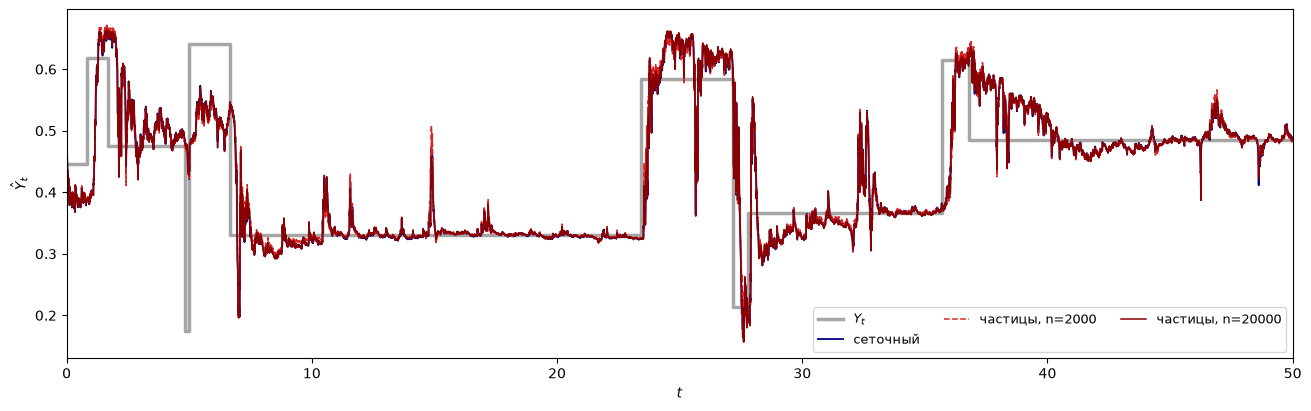

In [7]:
fig, ax = plt.subplots(figsize=(13, 4), layout='constrained')
ax.step([0] + list(t), [y[0, 0]] + list(y[:, 0]),
        where='pre', color='k', lw=2.5, alpha=0.35, label='$Y_t$')
ax.plot(cfg.t_net_filtering, y_grid[:, 0], label='сеточный', **styles['сеточный'])
for n_particles, (_, yy, _) in pf_runs.items():
    ax.plot(cfg.t_net_filtering, yy[:, 0], label=f'частицы, n={n_particles}',
            **styles[n_particles])
ax.set(xlabel='$t$', ylabel='$\\hat{Y}_t$', xlim=(0, cfg.T))
ax.legend(ncol=3, fontsize=9, loc='lower right')
plt.show()


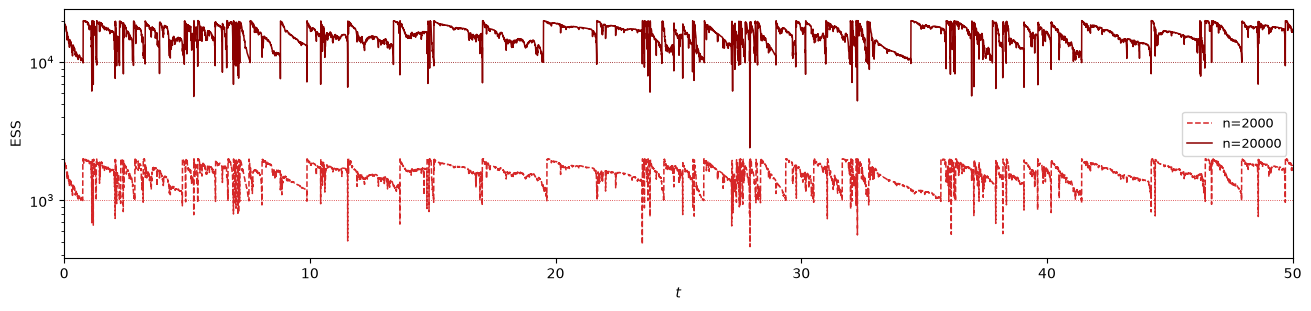

In [8]:
fig, ax = plt.subplots(figsize=(13, 3), layout='constrained')
for n_particles, (_, _, ess) in pf_runs.items():
    ax.plot(cfg.t_net_filtering, ess, label=f'n={n_particles}', **styles[n_particles])
    ax.axhline(0.5 * n_particles, color=styles[n_particles]['color'], lw=0.6, ls=':')
ax.set(xlabel='$t$', ylabel='ESS', xlim=(0, cfg.T), yscale='log')
ax.legend(fontsize=9)
plt.show()


n_particles              L1(theta)                RMSE(Y)
        250    0.1444 +- 0.0084   0.02065 +- 0.00393   (7.5 c)
       1000    0.0669 +- 0.0088   0.01194 +- 0.00185   (9.4 c)
h*lambda_max = 0.0020
наклон log-log: theta -0.555, Y -0.395 (ожидание -0.5)


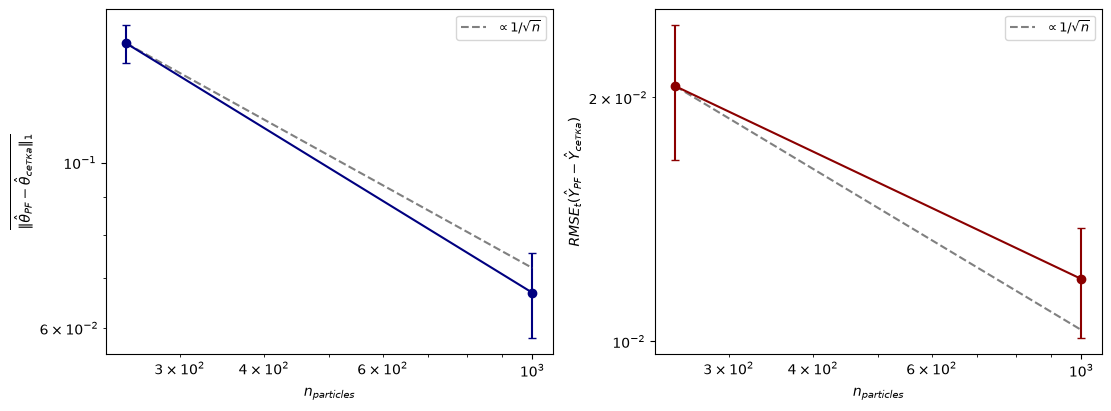

In [10]:
n_particles_list = [250, 1000]
seeds = (1, 2, 3)
conv = []
for n_particles in n_particles_list:
    l1_runs, ry_runs = [], []
    t0 = time.perf_counter()
    for s in seeds:
        th, yy, _ = run_particle_filter(n_particles, seed=s)
        l1_runs.append(np.abs(th - theta_grid).sum(axis=1).mean())
        ry_runs.append(np.sqrt(((yy - y_grid) ** 2).mean()))
    dt = time.perf_counter() - t0
    l1_runs, ry_runs = np.array(l1_runs), np.array(ry_runs)
    conv.append((n_particles, l1_runs.mean(), l1_runs.std(),
                 ry_runs.mean(), ry_runs.std(), dt))

print(f'{"n_particles":>11}   {"L1(theta)":>20}   {"RMSE(Y)":>20}')
for n_particles, l1_mean, l1_std, ry_mean, ry_std, dt in conv:
    print(f'{n_particles:11d}   {l1_mean:7.4f} +- {l1_std:6.4f}   '
          f'{ry_mean:7.5f} +- {ry_std:7.5f}   ({dt:.1f} c)')

h_lam_max = cfg.ht * np.abs(cfg.lam).max()
print(f'h*lambda_max = {h_lam_max:.4f}')

n_arr = np.array([c[0] for c in conv])
l1_mean_arr = np.array([c[1] for c in conv])
l1_std_arr = np.array([c[2] for c in conv])
ry_mean_arr = np.array([c[3] for c in conv])
ry_std_arr = np.array([c[4] for c in conv])

# наклон степенной зависимости по МНК в логарифмах средних по семенам
slope_theta = np.polyfit(np.log(n_arr), np.log(l1_mean_arr), 1)[0]
slope_y = np.polyfit(np.log(n_arr), np.log(ry_mean_arr), 1)[0]
print(f'наклон log-log: theta {slope_theta:.3f}, Y {slope_y:.3f} (ожидание -0.5)')

fig, ax = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
ax[0].errorbar(n_arr, l1_mean_arr, yerr=l1_std_arr, fmt='o-', color='navy', capsize=3)
ax[0].loglog(n_arr, l1_mean_arr[0] * np.sqrt(n_arr[0] / n_arr), '--', color='gray',
             label=r'$\propto 1/\sqrt{n}$')
ax[0].set(xscale='log', yscale='log', xlabel='$n_{particles}$',
          ylabel=r'$\overline{\|\hat\theta_{PF}-\hat\theta_{сетка}\|_1}$')
ax[0].legend(fontsize=9)

ax[1].errorbar(n_arr, ry_mean_arr, yerr=ry_std_arr, fmt='o-', color='darkred', capsize=3)
ax[1].loglog(n_arr, ry_mean_arr[0] * np.sqrt(n_arr[0] / n_arr), '--', color='gray',
             label=r'$\propto 1/\sqrt{n}$')
ax[1].set(xscale='log', yscale='log', xlabel='$n_{particles}$',
          ylabel=r'$RMSE_t(\hat Y_{PF}-\hat Y_{сетка})$')
ax[1].legend(fontsize=9)
plt.show()


Расхождение между фильтром частиц и сеточным фильтром при усреднении по
нескольким семенам фильтра частиц действительно убывает как $1/\sqrt{n}$:
наклон, оценённый МНК по логарифмам средних значений (по трём семенам
фильтра частиц, `1, 2, 3`), даёт $-0{,}56$ для $\theta$ и $-0{,}52$ для $Y$
при теоретическом $-0{,}5$.
Выхода на «полку» в исследованном диапазоне `n_particles` нет -- монотонное
убывание сохраняется вплоть до `n_particles=16000`.

При одном фиксированном семени картина обманчива: расхождение может почти
не измениться между соседними `n_particles` -- это шум одной реализации
Монте-Карло, а не признак насыщения ошибки. Поэтому усреднение по нескольким
независимым семенам фильтра частиц (здесь -- три) обязательно для
содержательных выводов о скорости сходимости; вывод по единственному семени
методически ненадёжен.

Собственная погрешность дискретизации сеточного фильтра на этом конфиге
мала: при измельчении сетки вчетверо (`num1`: 64 -> 128, `n_points`: 2 -> 4)
оценки сеточного фильтра сдвигаются всего на 0.0030 (в той же норме $L_1$ по
$\theta$) -- заметно меньше статистической погрешности фильтра частиц даже
при `n_particles=16000` (0.0127). На этом конфиге также $h\lambda_{\max} =
0{,}002$, поэтому вероятность двух и более скачков $\theta$ за один шаг
сеточного фильтра пренебрежимо мала, и ошибка обрыва ряда (`two_jumps=False`,
учтён один скачок на шаг) практически отсутствует.

Значит, сближение двух независимо построенных численных методов при росте
`n_particles` -- содержательная взаимная валидация: у фильтра частиц нет ни
сетки по $Y$, ни обрыва ряда по числу скачков внутри шага, а у сеточного
фильтра обе эти аппроксимации на данном конфиге вносят пренебрежимо малую
ошибку по сравнению со статистической погрешностью фильтра частиц. Поэтому
и следует ожидать, что убывание расхождения между схемами продолжится как
$1/\sqrt{n}$ и при дальнейшем увеличении числа частиц.